In [3]:
import pandas as pd
df=pd.read_csv("USvideos.csv")
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=df.dropna()

In [4]:
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['trending_date'] = pd.to_datetime(df['trending_date'], format='%y.%d.%m')

In [5]:
pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 1.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
from textblob import TextBlob

df['sentiment'] = df['title'].apply(
    lambda x: TextBlob(x).sentiment.polarity
)

In [7]:
df['sentiment_label'] = df['sentiment'].apply(
    lambda x: 'Positive' if x > 0 else 'Negative' if x < 0 else 'Neutral'
)

In [8]:
category_views = df.groupby('category_id')['views'].mean().sort_values(ascending=False)
print(category_views)

category_id
10    6.210307e+06
29    3.167400e+06
1     3.112240e+06
20    2.647433e+06
24    2.073128e+06
17    2.069401e+06
22    1.529018e+06
23    1.483936e+06
28    1.382127e+06
2     1.373286e+06
26    9.849565e+05
43    9.035273e+05
19    8.546196e+05
15    8.347004e+05
27    7.187950e+05
25    6.008645e+05
Name: views, dtype: float64


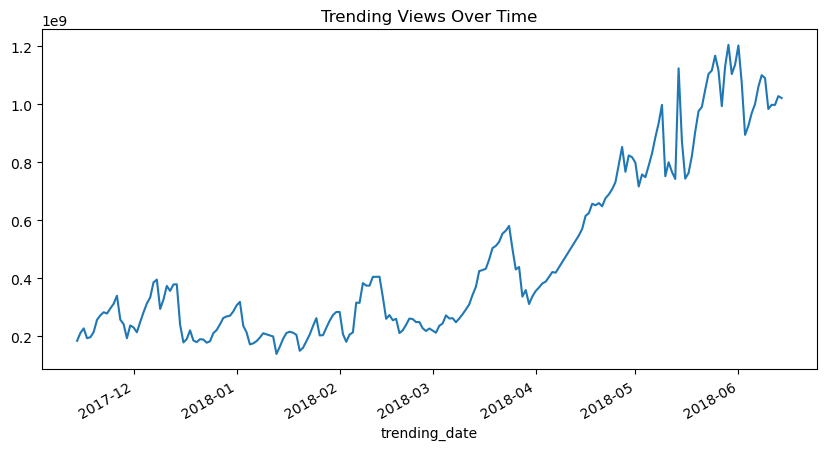

In [9]:
daily_views = df.groupby('trending_date')['views'].sum()

plt.figure(figsize=(10,5))
daily_views.plot()
plt.title("Trending Views Over Time")
plt.show()

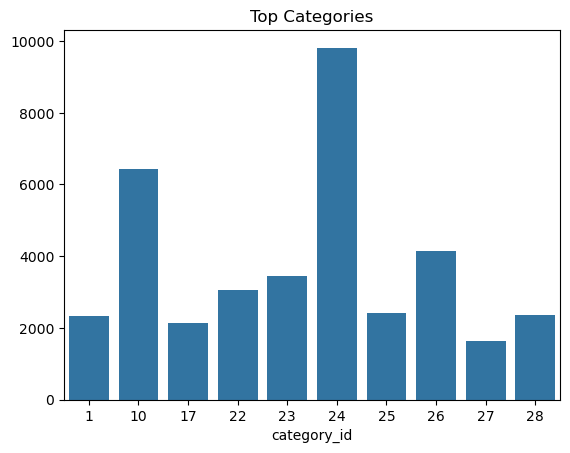

In [10]:
top_categories = df['category_id'].value_counts().head(10)

sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title("Top Categories")
plt.show()

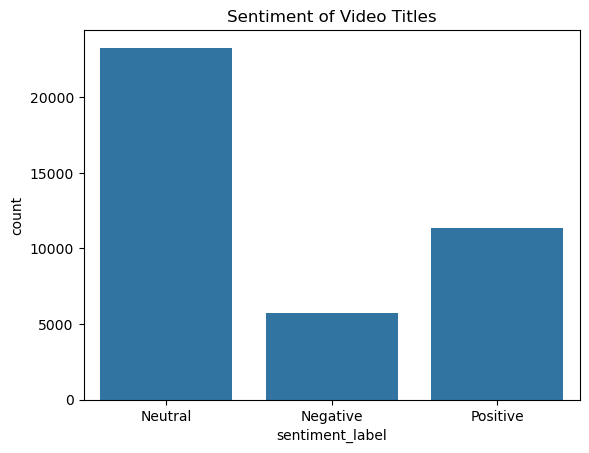

In [11]:
sns.countplot(x='sentiment_label', data=df)
plt.title("Sentiment of Video Titles")
plt.show()

In [12]:
df['region'] = "US"   # Change per dataset

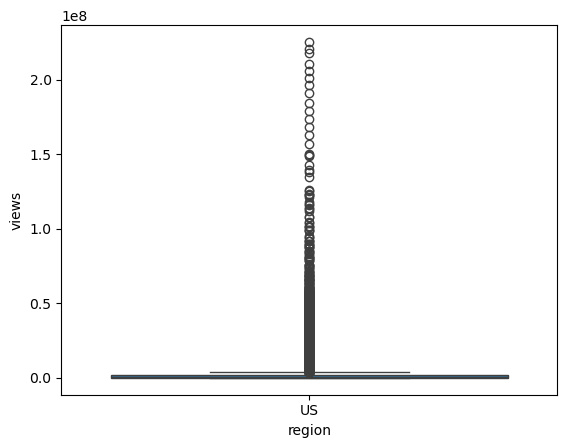

In [13]:
sns.boxplot(x='region', y='views', data=df)
plt.show()

In [5]:
df_in = pd.read_csv("INvideos.csv")
df_gb = pd.read_csv("GBvideos.csv")
df_ca = pd.read_csv("CAvideos.csv")

df_in['region'] = 'India'
df_gb['region'] = 'UK'
df_ca['region'] = 'Canada'

df_all = pd.concat([df, df_in, df_gb, df_ca])

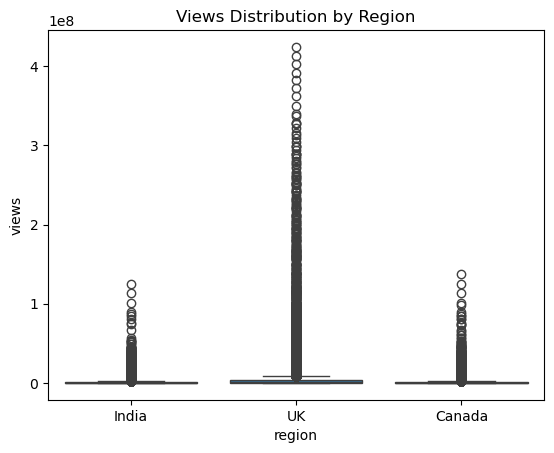

In [10]:

df_all = df_all.reset_index(drop=True)

sns.boxplot(x='region', y='views', data=df_all)
plt.title("Views Distribution by Region")
plt.show()



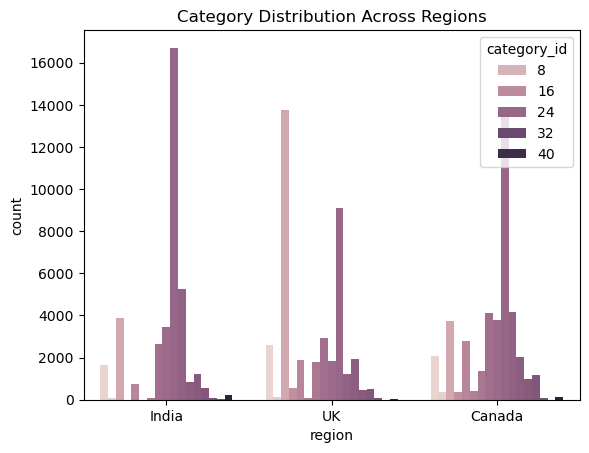

In [11]:
sns.countplot(x='region', hue='category_id', data=df_all)
plt.title("Category Distribution Across Regions")
plt.show()


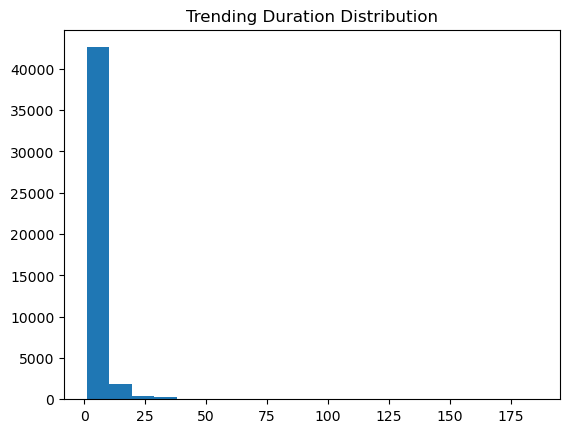

In [15]:
duration = df_all.groupby('video_id')['trending_date'].nunique()

plt.hist(duration, bins=20)
plt.title("Trending Duration Distribution")
plt.show()

In [16]:
df_all.to_csv("youtube_trending_cleaned.csv", index=False)